In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 6, "cos": 6}',
        '--fun_trans', '{"data": 10}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.266421, valid=0.042775, test=0.043319
	validation loss decreased (inf -> 0.042775), saving model ...
	epoch 2 losses: train=0.138189, valid=0.023704, test=0.023667
	validation loss decreased (0.042775 -> 0.023704), saving model ...
	epoch 3 losses: train=0.060186, valid=0.009821, test=0.009847
	validation loss decreased (0.023704 -> 0.009821), saving model ...
	epoch 4 losses: train=0.006565, valid=0.008448, test=0.008494
	validation loss decreased (0.009821 -> 0.008448), saving model ...
	epoch 5 losses: train=0.005246, valid=0.008418, test=0.008401
	validation loss decreased (0.008448 -> 0.008418), saving model ...
	epoch 6 losses: train=0.004541, valid=0.006497, test=0.006427
	validation loss decreased (0.008418 -> 0.006497), saving model ...
	epoch 7 losses: train=0.003979, valid=0.009914, test=0.009662
	early stopping counter: 1 out of 10
	epoch 8 losses: train=0.003736, valid=0.006000, test=0.006069
	validation loss decreased

In [6]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

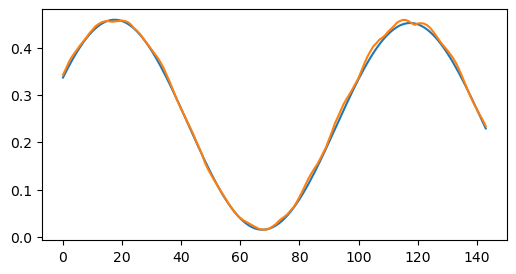

In [7]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [8]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=-0.370884, valid=-0.512495, test=-0.530702
	validation loss decreased (inf -> -0.512495), saving model ...
	epoch 2 losses: train=-0.872898, valid=-0.609812, test=-0.632359
	validation loss decreased (-0.512495 -> -0.609812), saving model ...
	epoch 3 losses: train=-0.962898, valid=-0.607794, test=-0.619584
	early stopping counter: 1 out of 10
	epoch 4 losses: train=-0.986482, valid=-0.711485, test=-0.716401
	validation loss decreased (-0.609812 -> -0.711485), saving model ...
	epoch 5 losses: train=-1.058414, valid=-0.784913, test=-0.806245
	validation loss decreased (-0.711485 -> -0.784913), saving model ...
	epoch 6 losses: train=-1.100905, valid=-0.820739, test=-0.833661
	validation loss decreased (-0.784913 -> -0.820739), saving model ...
	epoch 7 losses: train=-1.137566, valid=-0.856884, test=-0.871160
	validation loss decreased (-0.820739 -> -0.856884), saving model ...
	epoch 8 losses: train=-1.168095, valid=-0.877523,

In [9]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

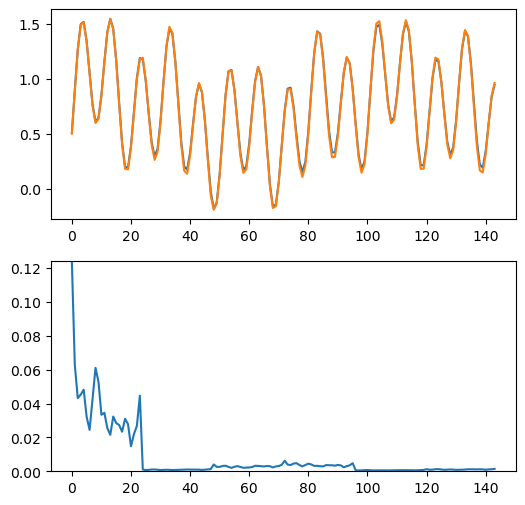

In [10]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [11]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=0.232393, valid=0.180970, test=0.180920
	validation loss decreased (inf -> 0.180970), saving model ...
	epoch 2 losses: train=0.118507, valid=0.104159, test=0.103488
	validation loss decreased (0.180970 -> 0.104159), saving model ...
	epoch 3 losses: train=0.065394, valid=0.088811, test=0.088896
	validation loss decreased (0.104159 -> 0.088811), saving model ...
	epoch 4 losses: train=0.055680, valid=0.070307, test=0.070798
	validation loss decreased (0.088811 -> 0.070307), saving model ...
	epoch 5 losses: train=0.043766, valid=0.056682, test=0.056768
	validation loss decreased (0.070307 -> 0.056682), saving model ...
	epoch 6 losses: train=0.034914, valid=0.047914, test=0.048653
	validation loss decreased (0.056682 -> 0.047914), saving model ...
	epoch 7 losses: train=0.032069, valid=0.044136, test=0.044462
	validation loss decreased (0.047914 -> 0.044136), saving model ...
	epoch 8 losses: train=0.030628, valid=0.044001, test=0.044

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='trans')

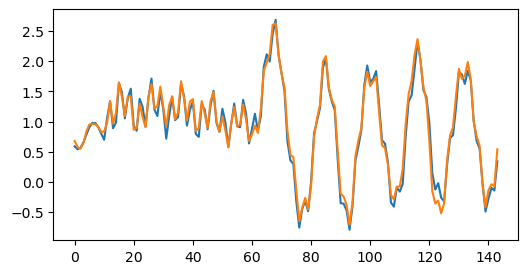

In [13]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [14]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=-0.428128, valid=-0.756332, test=0.293743
	validation loss decreased (inf -> -0.756332), saving model ...
	epoch 2 losses: train=-1.030977, valid=-0.949176, test=-0.917875
	validation loss decreased (-0.756332 -> -0.949176), saving model ...
	epoch 3 losses: train=-1.067935, valid=-0.989521, test=-0.956232
	validation loss decreased (-0.949176 -> -0.989521), saving model ...
	epoch 4 losses: train=-1.301571, valid=-1.041196, test=-0.990180
	validation loss decreased (-0.989521 -> -1.041196), saving model ...
	epoch 5 losses: train=-1.349782, valid=-1.031841, test=-0.980217
	early stopping counter: 1 out of 10
	epoch 6 losses: train=-1.378952, valid=-1.058572, test=-1.005298
	validation loss decreased (-1.041196 -> -1.058572), saving model ...
	epoch 7 losses: train=-1.408998, valid=-1.058955, test=-0.995625
	validation loss decreased (-1.058572 -> -1.058955), saving model ...
	epoch 8 losses: train=-1.432116, valid=-1.083908, t

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

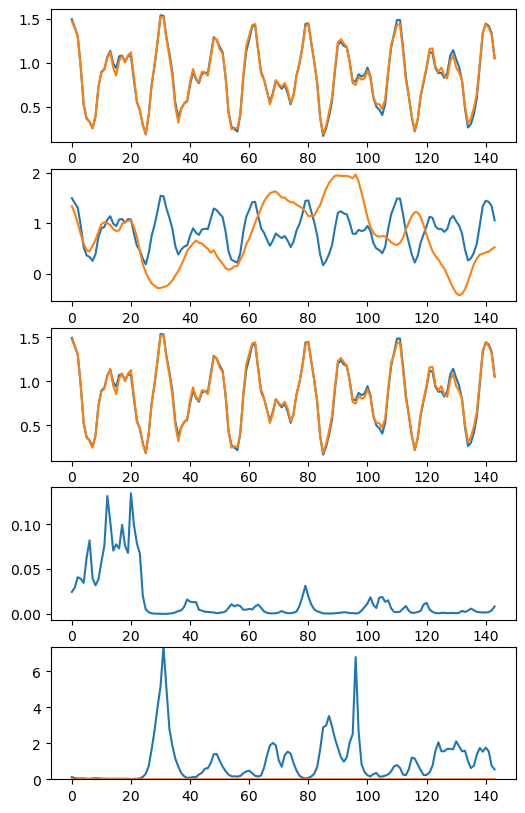

In [18]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break